## Import & Load Data

In [1]:
# Import tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/churn_cleaned.csv')
print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (7043, 23)


## Churn Distribution

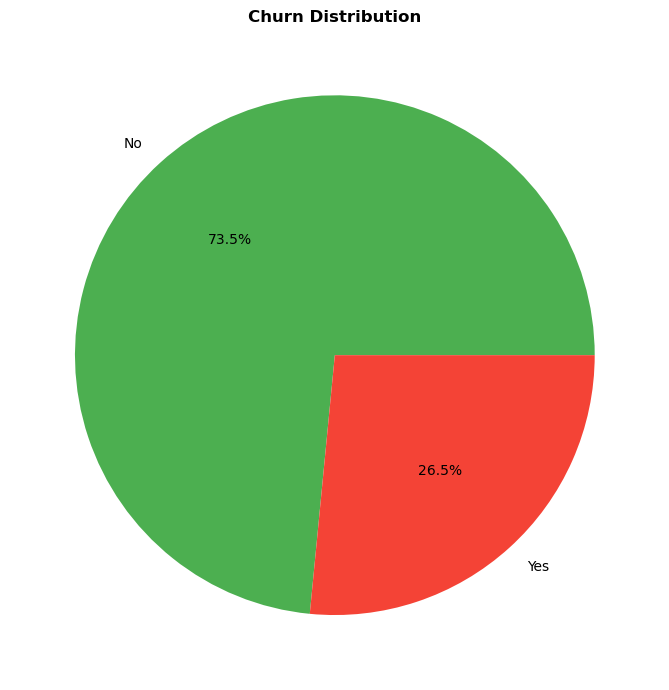

Chart saved!


In [6]:
# value_counts() counts how many Yes and No in Churn column
churn_count = df['Churn'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(churn_count, 
        labels=churn_count.index,
        autopct='%1.1f%%',        # shows percentage like 26.5%
        colors=['#4CAF50', '#F44336'])
plt.title('Churn Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/churn_distribution.png')
plt.show()
print("Chart saved!")

## Churn by Contract Type

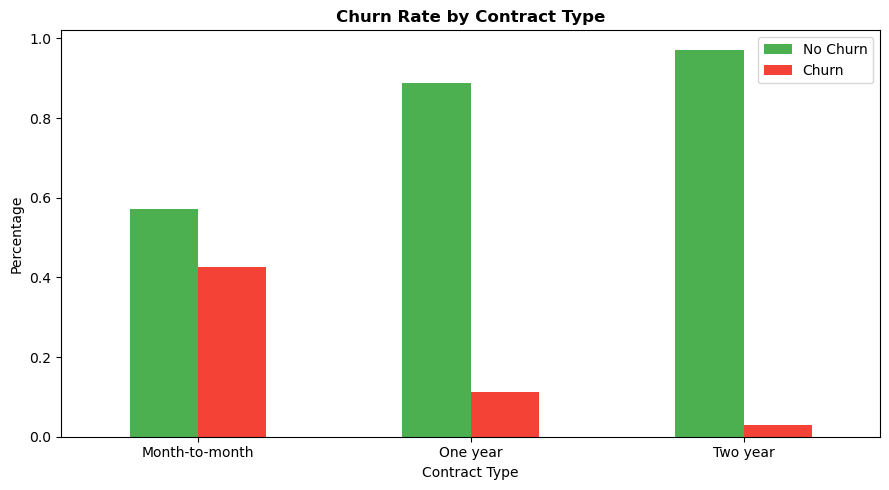

Chart saved!


In [7]:
# groupby Contract → then count Churn values
# normalize=True converts counts to percentages
# unstack() converts it into a table with Yes/No columns
contract_churn = df.groupby('Contract')['Churn']\
                   .value_counts(normalize=True)\
                   .unstack()

contract_churn.plot(kind='bar', figsize=(9, 5),
                    color=['#4CAF50', '#F44336'])
plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('../outputs/churn_by_contract.png')
plt.show()
print("Chart saved!")

## Monthly Charges vs Churn

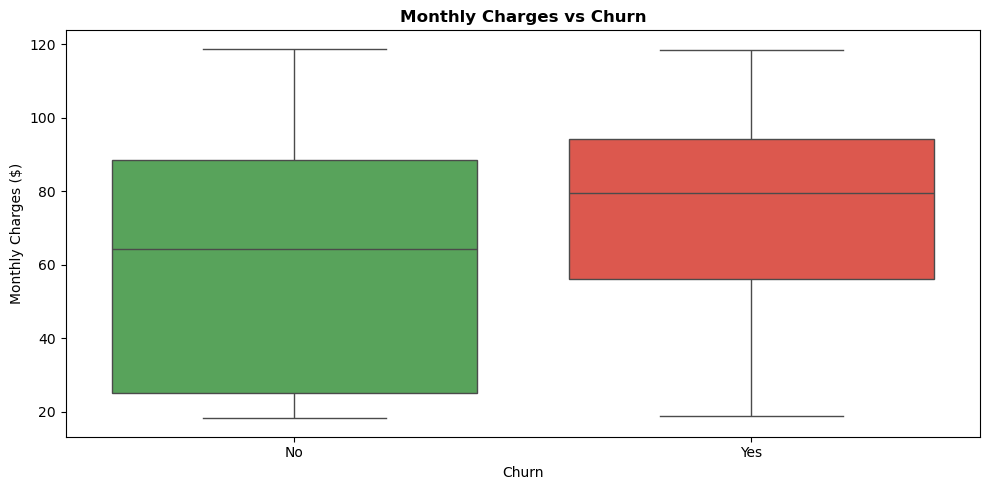

Chart saved!


In [9]:
plt.figure(figsize=(10, 5))

# boxplot shows the range of monthly charges
# for churned vs not churned customers
# it helps us see if high paying customers churn more
sns.boxplot(x='Churn', 
            y='MonthlyCharges',
            data=df,
            palette={'Yes': '#F44336', 'No': '#4CAF50'})

plt.title('Monthly Charges vs Churn', fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('../outputs/charges_vs_churn.png')
plt.show()
print("Chart saved!")